In [1]:
import time
import numpy as np
import pandas as pd
import pyrepseq as prs
import pyrepseq.plotting as pp
import pwseqdist
import symscan
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from scipy.cluster.hierarchy import fcluster, linkage

DATADIR = '/media/andreas/data/data/fastclustering'

# number of top V/J/length combinations to analyze
topn = 100
# proportional cdr3 nt length cutoff for identifying putative clonal lineages
prop_length_cutoff = 0.15

plt.style.use('bmh')

In [ ]:
df = pd.read_csv(f'{DATADIR}/316188.tsv.gz',
                usecols=['sequence_id', 'v_call', 'j_call', 'junction'], sep='\t', index_col=0)
df.rename(columns={'v_call': 'v_gene', 'j_call': 'j_gene', 'junction': 'cdr3_nt'}, inplace=True)
df.drop_duplicates(subset=['v_gene', 'j_gene', 'cdr3_nt'], inplace=True)
df['cdr3_length'] = df['cdr3_nt'].str.len()

In [ ]:
np.mean(df['cdr3_length'])*prop_length_cutoff

np.float64(7.530989572132713)

In [ ]:
'Number of sequences: %e'%len(df)

'Number of sequences: 9.305680e+05'

In [ ]:
vjls = (df
        .value_counts(['v_gene', 'j_gene', 'cdr3_length'])
        .to_frame('sequence_count')
        .reset_index()
    )

Text(0, 0.5, 'Rank')

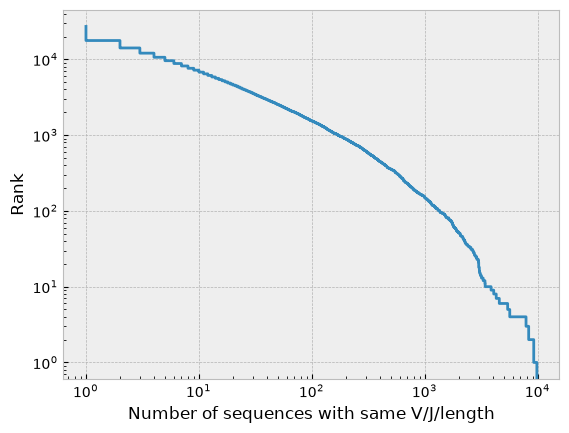

In [ ]:
prs.plotting.rankfrequency(vjls['sequence_count'], normalize_x=False)
plt.xlabel('Number of sequences with same V/J/length')
plt.ylabel('Rank')

In [ ]:
dfs = []
for i in range(topn):
    v, j, l = vjls.iloc[i][['v_gene', 'j_gene', 'cdr3_length']]
    dfs.append(df[(df['v_gene'] == v) & (df['j_gene'] == j) & (df['cdr3_length'] == l)]['cdr3_nt'])
min([len(d) for d in dfs]), max([len(d) for d in dfs])

(1357, 9814)

In [ ]:
def symscan_neighbors(sample, k, max_edits):
    l = len(sample.iloc[0])
    start = int(l//2-k//2)
    end = start + k
    seqs = list(sample.str.slice(start, end))
    (row, col, dists) = symscan.get_neighbors_within(seqs, max_distance=max_edits, distance_type='hamming')
    edges = np.column_stack((row, col))
    filtered = pwseqdist.apply_pairwise_sparse(metric=pwseqdist.metrics.nb_vector_hamming_distance,
                            seqs=np.asarray(sample, dtype=str), pairs=edges, use_numba=True)
    return filtered

In [ ]:
k = 6
max_editss = [1, 2, 3]

times_exhaustive = []
times_symscan = {}
fractions = {}
for max_edits in max_editss:
    fractions[max_edits] = []
    times_symscan[max_edits] = []
for sample in dfs:
    told = time.time()
    pdists = prs.squareform(pwseqdist.apply_pairwise_rect(metric=pwseqdist.metrics.nb_vector_hamming_distance,
                        seqs1=np.asarray(sample, dtype=str), seqs2=None, use_numba=True))
    times_exhaustive.append(time.time()-told)
    told = time.time()

    for max_edits in [1, 2, 3]:
        told = time.time()
        pdists_symscan = symscan_neighbors(sample, k=k, max_edits=max_edits)
        times_symscan[max_edits].append(time.time()-told)
        fractions[max_edits].append(np.sum(pdists_symscan<l*prop_length_cutoff)/np.sum(pdists<l*prop_length_cutoff))
fractions = {k: np.array(v) for k, v in fractions.items()}

In [ ]:
[np.mean(fractions[i]) for i in [1, 2, 3]]

[np.float64(0.872661430616108),
 np.float64(0.9724226915685981),
 np.float64(0.9953529501829272)]

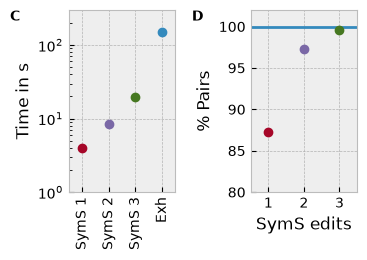

In [ ]:
fig, axes = plt.subplots(figsize=(3.42, 2.4), ncols=2)
for max_edits in [1, 2, 3]:
    axes[0].plot(f'SymS {max_edits}', np.sum(times_symscan[max_edits]), 'o', color=f'C{max_edits}')
    axes[1].plot([max_edits], [np.mean(fractions[max_edits])*100], 'o', color=f'C{max_edits}', zorder=3)
axes[0].plot('Exh', np.sum(times_exhaustive), 'o', color='C0')
axes[0].tick_params(axis='x', labelrotation=90)
axes[0].set_ylabel('Time in s')
axes[0].set_yscale('log')
axes[0].set_ylim(1e0, 3e2)
axes[0].set_xlim(-0.5, 3.5)
axes[1].axhline(y=100, color='C0', ls='-', zorder=2)
axes[1].set_xlabel('SymS edits')
axes[1].set_ylabel('% Pairs')
axes[1].set_ylim(80, 102)
axes[1].set_xlim(0.5, 3.5)
fig.tight_layout(w_pad=1.5, pad=0.0)
prs.plotting.label_axes(fig, xy=(-0.55, 1.0), labels='CD')
fig.savefig('antibody_benchmark.svg')

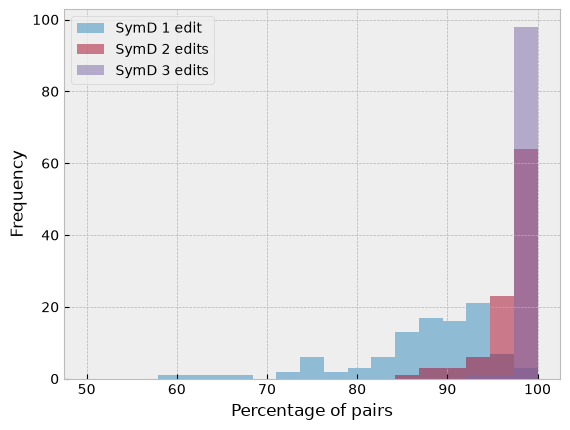

In [ ]:
plt.hist(fractions[1]*100, bins=np.linspace(50, 100, 20), alpha=0.5, label='SymD 1 edit')
plt.hist(fractions[2]*100, bins=np.linspace(50, 100, 20), alpha=0.5, label='SymD 2 edits')
plt.hist(fractions[3]*100, bins=np.linspace(50, 100, 20), alpha=0.5, label='SymD 3 edits')
plt.xlabel('Percentage of pairs')
plt.ylabel('Frequency')
plt.legend()
plt.show()

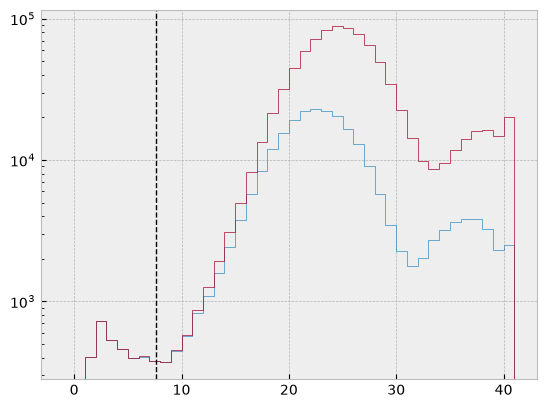

In [ ]:
plt.hist(pdists_symscan, bins=np.arange(-1, 42, 1), histtype='step')
plt.hist(pdists, bins=np.arange(-1, 42, 1), histtype='step')
plt.axvline(l*0.15, color='k', ls='--', lw=1)
plt.yscale('log')